## XGBoost

**Objetivo:** desenvolver e avaliar modelos de previsão de PM2.5 com horizonte de 24 horas utilizando o algoritmo XGBoost (Extreme Gradient Boosting). O modelo incorpora variáveis meteorológicas, atributos temporais cíclicos, lags históricos da série e indicador sazonal de inverno.

*******
**Exploração e entendimento dos dados**
- Análise de ciclos sazonais (horário, semanal e anual) de PM2.5 e variáveis 
  meteorológicas;
- Correlação cruzada com lag entre PM2.5 e variáveis meteorológicas para 
  identificação de defasagens relevantes;
- Investigação da variabilidade mensal para identificação de períodos críticos 
  (inverno — junho a agosto).

************

**Experimentos XGBoost**

Foram realizados diversos experimentos com o modelo XGBoost para previsão de PM2.5 com horizonte de 24 horas. Os testes avaliaram diferentes configurações de:

- Inclusão de variáveis meteorológicas (temperatura, umidade relativa, precipitação e velocidade do vento);
- Inclusão de atributos temporais cíclicos (mês, dia da semana e hora representados por funções seno e cosseno);
- Inclusão de séries de Fourier para representação de sazonalidades de longo prazo;
- Diferentes conjuntos de lags da variável PM2.5;
- Ajuste dos hiperparâmetros do modelo.

************

**Conjunto de dados base utilizado**

      - 100% dos dados entre 2016-2019
      - train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
      - val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
      - test : (5499, 7) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00

************

**Melhor Experimento**

- Modelo: XGBoost
- Hiperparâmetros: otimizados via Gridsearch (notebook Gabriel):

      (colsample_bytree=0.8, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=500, reg_alpha=0.1, reg_lambda=10, subsample=0.8)

- Variáveis exógenas: temperatura, umidade relativa e velocidade do vento
- Features engineering: temporais cíclicas + lags PM2.5 [1,2,3,6,12,24,48,168h]
  + lags meteorológicos [1,3,6,12,24h] + is_winter + rolling [6,12,24,48h]
- Tratamento de dados faltantes: interpolação com a média sazonal

- Conjunto de dados: 100% dos dados (2016-2019)

      - train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
      - val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
      - test : (5499, 7) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00

- Resultados obtidos no conjunto de validação em média:
    - MAE : 4,19 µg/m³
    - RMSE: 5,34 µg/m³
    - R²  : 0,31

- Resultados obtidos no conjunto de teste em média:

    - MAE : 4,80 µg/m³
    - RMSE: 6,14 µg/m³
    - R²  : 0,33


Em comparação ao LightGBM, os resultados do XGBoost foram muito semelhantes. Na validação, o LightGBM obteve MAE 1,2% menor e R² ligeiramente superior (0,33 vs 0,31). No conjunto de teste, o XGBoost apresentou 
MAE maior (4,80 vs 4,71 µg/m³). 

O LightGBM é mantido como modelo de referência para comparações subsequentes por apresentar resultado ligeiramente superior na validação, 
que é o conjunto usado para seleção de modelos.

In [34]:
%matplotlib widget

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import shap

shap.initjs();

### 1. Carregamento dos dados

In [36]:
# abrindo base de dados para treinamento/teste/validação
data = pd.read_csv("../data/data_interpolacao_gaps_maiores_medias/dados_full_features_2016_2019_fill_mean.csv")
#data = pd.read_csv("../data/data_sem_interpolacao/dados_full_feature_2016_2019_nan.csv")
data.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [37]:
data["time"] = pd.to_datetime(data["time"])
data = data.set_index("time").sort_index()

data.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


### 2. Exploração da Série Temporal (Ciclos)

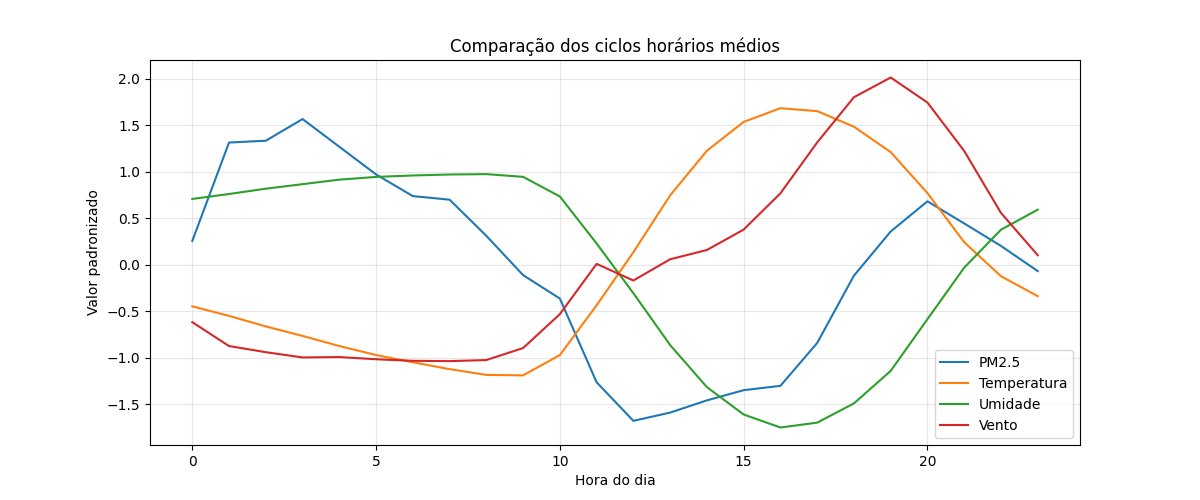

In [38]:
#ciclo diário
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.hour)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.hour)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.hour)["relative_humidity_2m"].mean(),
    "Vento": data.groupby(data.index.hour)["wind_speed_10m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos horários médios")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.show()

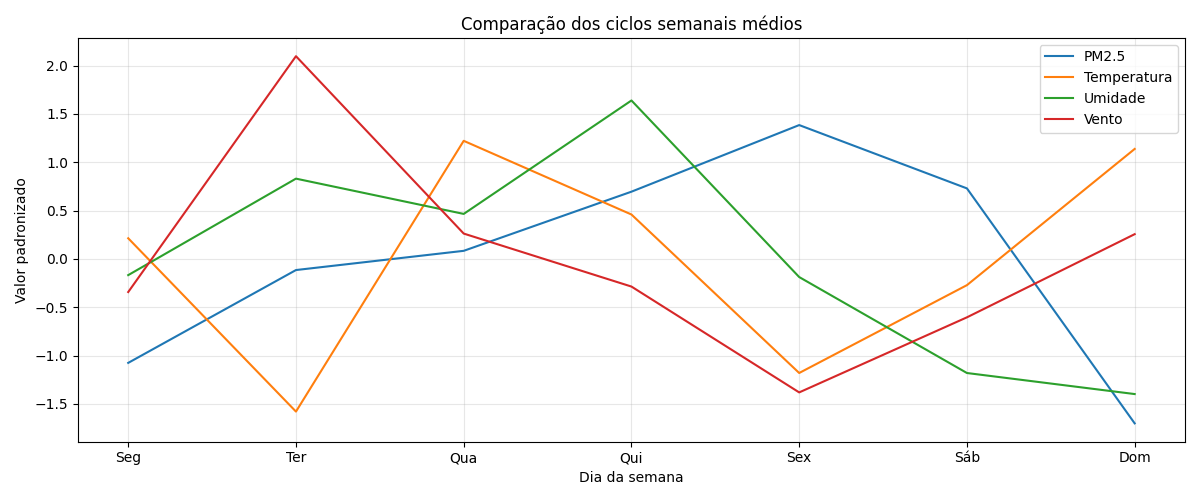

In [39]:
# ciclo semanal
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.dayofweek)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.dayofweek)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.dayofweek)["relative_humidity_2m"].mean(),
    "Vento": data.groupby(data.index.dayofweek)["wind_speed_10m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
ciclo_norm.index = dias

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos semanais médios")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

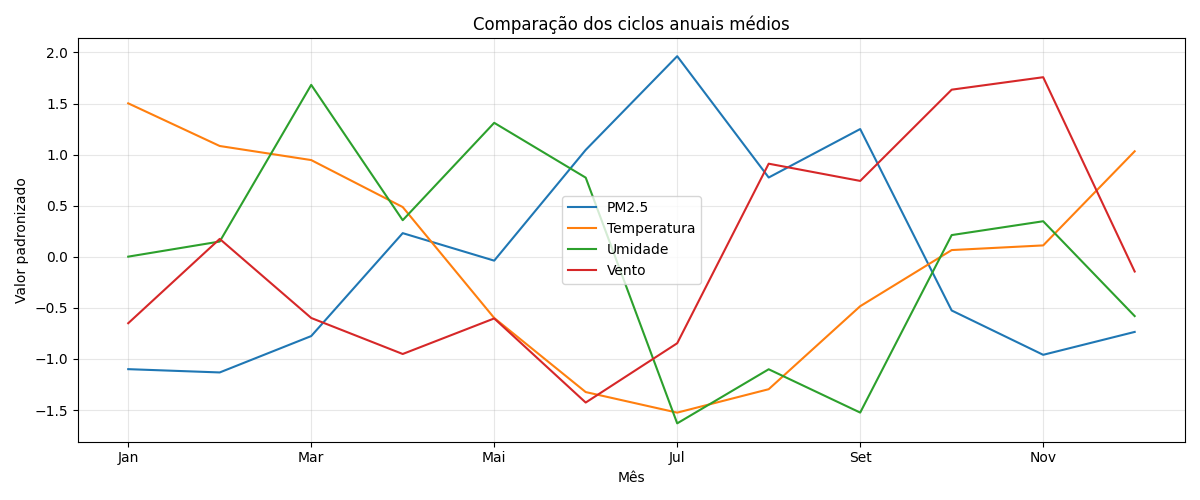

In [40]:
# ciclo anual
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.month)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.month)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.month)["relative_humidity_2m"].mean(),
    "Vento": data.groupby(data.index.month)["wind_speed_10m"].mean()
})


ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

meses = [
    "Jan", "Fev", "Mar", "Abr",
    "Mai", "Jun", "Jul", "Ago",
    "Set", "Out", "Nov", "Dez"
]

ciclo_norm.index = meses

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos anuais médios")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Correlação entre variáveis

In [41]:
######### Temperatura e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_temp = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["temperature_2m"].shift(lag)
    )

    corr_temp.append(c)

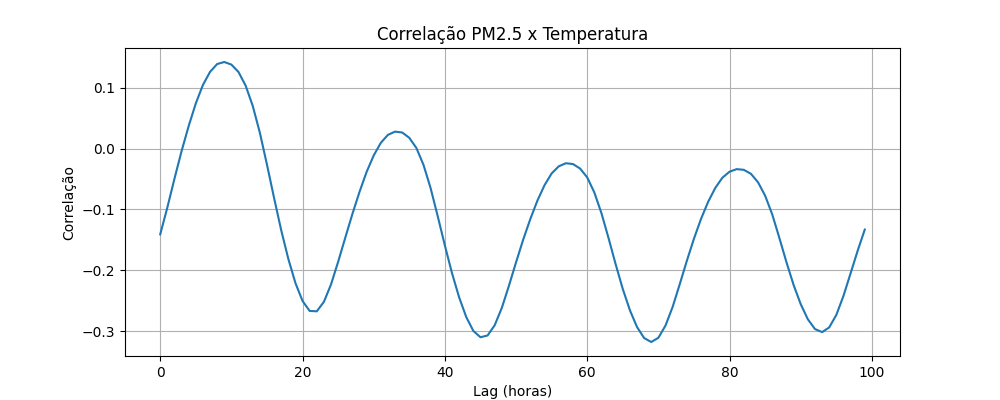

In [42]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Temperatura")
plt.grid()

plt.show()

In [43]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi.append(c)

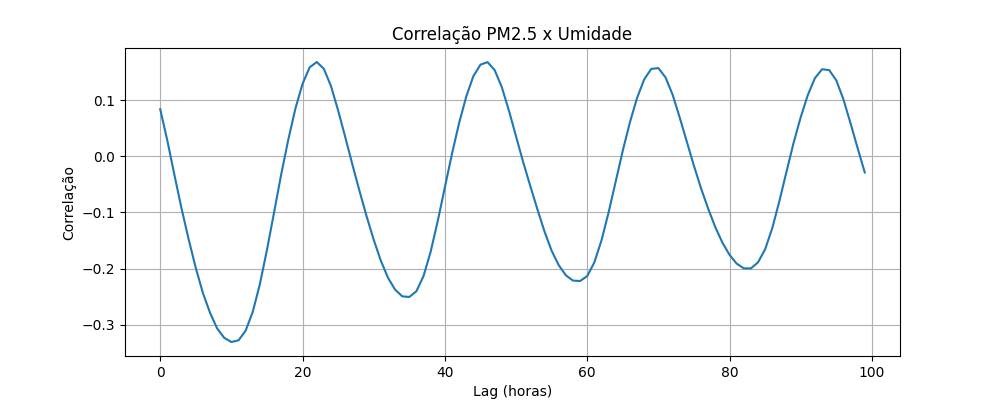

In [44]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Umidade")
plt.grid()

plt.show()

In [45]:
corr_pm25 = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["MP2.5"].shift(lag)
    )

    corr_pm25.append(c)

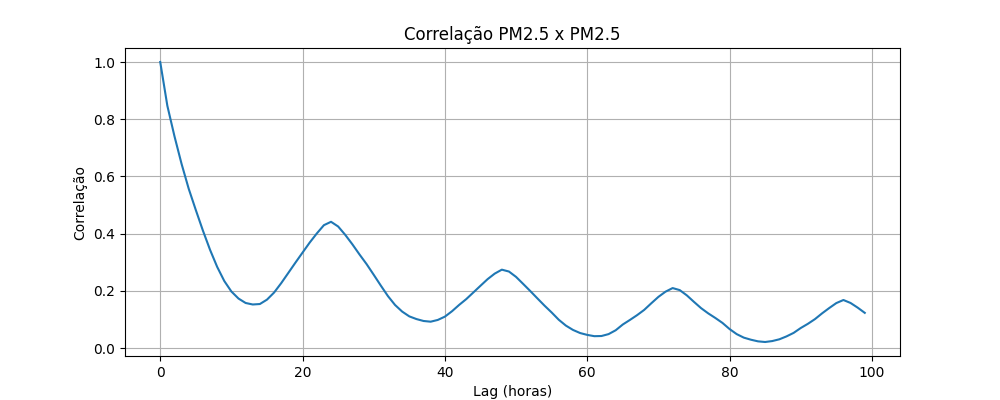

In [46]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_pm25)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x PM2.5")
plt.grid()

plt.show()

In [47]:
######### vento e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_vento = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["wind_speed_10m"].shift(lag)
    )

    corr_vento.append(c)

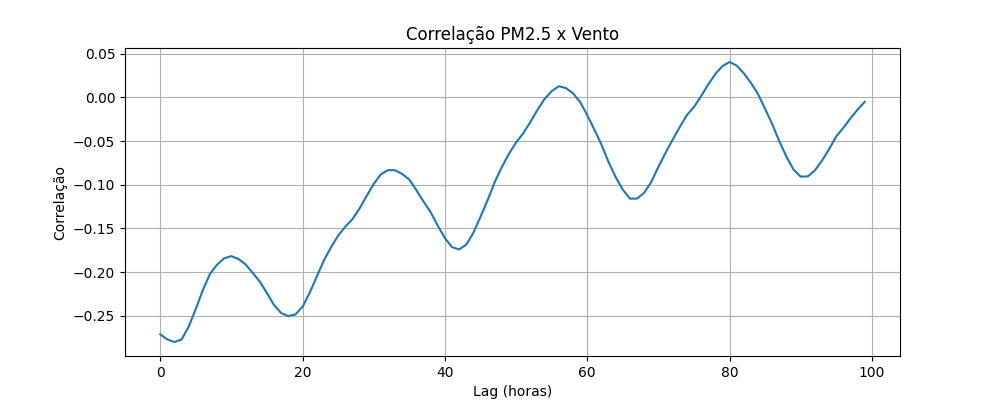

In [48]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_vento)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Vento")
plt.grid()

plt.show()

**Entendendo variabilidade anual**

In [49]:
pm25_mes = (data.groupby(data.index.month)["MP2.5"].mean())

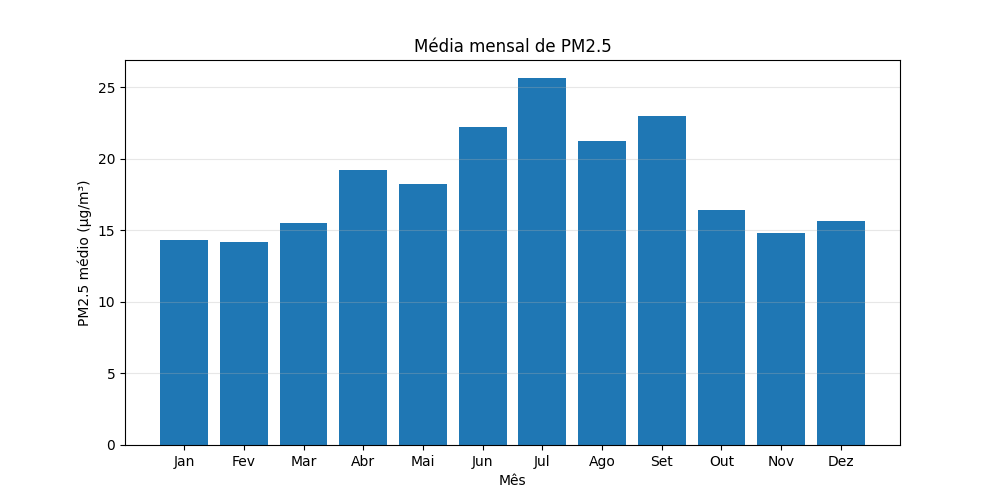

In [50]:
meses = [
    "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
    "Jul", "Ago", "Set", "Out", "Nov", "Dez"
]

plt.figure(figsize=(10,5))

plt.bar(
    meses,
    pm25_mes
)

plt.ylabel("PM2.5 médio (µg/m³)")
plt.xlabel("Mês")
plt.title("Média mensal de PM2.5")
plt.grid(axis="y", alpha=0.3)

plt.show()

### 4. Feature Engineering

In [51]:
data_xgboost = data.copy()

**Variáveis ciclicas temporais**

In [52]:
# Foram avaliadas diferentes features sazonais (ciclos diários, semanais e mensal) com o objetivo de melhorar a reprodução do modelo.
def cyclical_time_features(df):
    """
    Adiciona termos ciclicos como features exógenas
    df -> data

    """

    df = df.copy()

    df["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
    df["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)


    df["weekday_sin"] = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df.index.dayofweek / 7)


    df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)

    return df

In [53]:
data_xgboost = cyclical_time_features(data_xgboost)

In [54]:
data_xgboost.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos
time,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,1.000000
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,0.965926
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,0.866025
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,0.707107
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,0.500000


**Variáveis meteorológicas com lags**

In [55]:
# vou usar apenas temperatura, vento e umidade que parecem ter maior corelação com lag
met_vars = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
]

for var in met_vars:
    if var in data_xgboost.columns:
        for lag in [1, 3, 6, 12, 24]:
            data_xgboost[f"{var}_lag{lag}"] = data_xgboost[var].shift(lag)

data_xgboost.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,relative_humidity_2m_lag1,relative_humidity_2m_lag3,relative_humidity_2m_lag6,relative_humidity_2m_lag12,relative_humidity_2m_lag24,wind_speed_10m_lag1,wind_speed_10m_lag3,wind_speed_10m_lag6,wind_speed_10m_lag12,wind_speed_10m_lag24
time,,,,,,,,,,,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,...,95.075165,NaN,NaN,NaN,NaN,12.538134,NaN,NaN,NaN,NaN
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,...,95.983490,NaN,NaN,NaN,NaN,14.529915,NaN,NaN,NaN,NaN
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,...,95.380060,95.075165,NaN,NaN,NaN,12.538134,12.538134,NaN,NaN,NaN
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,...,96.285950,95.983490,NaN,NaN,NaN,11.525623,14.529915,NaN,NaN,NaN


In [56]:
# lag negativo = valor futuro da variável meteorológica
# na ferramenta operacional terei acesso às previsões atmosféricas.
# for var in ["temperature_2m", "relative_humidity_2m", "wind_speed_10m"]:
#     for h in [1, 3, 6, 12, 24]:
#         data_lgbm[f"{var}_future{h}"] = data_lgbm[var].shift(-h)

**Lags temporais do target (MP2.5)**

In [57]:
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    data_xgboost[f"pm25_lag{lag}"] = data_xgboost["MP2.5"].shift(lag)

data_xgboost.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,wind_speed_10m_lag12,wind_speed_10m_lag24,pm25_lag1,pm25_lag2,pm25_lag3,pm25_lag6,pm25_lag12,pm25_lag24,pm25_lag48,pm25_lag168
time,,,,,,,,,,,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,...,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,...,NaN,NaN,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,...,NaN,NaN,18.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,...,NaN,NaN,17.0,18.0,1.0,NaN,NaN,NaN,NaN,NaN


**indicador de inverno (mês de poluição mais extrema)**

In [58]:
# a reprodução dos meses de inverno teve o pior desempenho no SARIMAX
data_xgboost["is_winter"] = data_xgboost.index.month.isin([6, 7, 8]).astype(int)
data_xgboost.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,wind_speed_10m_lag24,pm25_lag1,pm25_lag2,pm25_lag3,pm25_lag6,pm25_lag12,pm25_lag24,pm25_lag48,pm25_lag168,is_winter
time,,,,,,,,,,,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,...,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,...,NaN,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,0
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,...,NaN,18.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,0
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,...,NaN,17.0,18.0,1.0,NaN,NaN,NaN,NaN,NaN,0


**Janela móvel (rolling)**

In [59]:
for window in [6, 12, 24, 48]:
    base = data_xgboost["MP2.5"].shift(1)
    data_xgboost[f"pm25_mean_{window}h"] = base.rolling(window).mean()
    data_xgboost[f"pm25_std_{window}h"]  = base.rolling(window).std()
    data_xgboost[f"pm25_max_{window}h"]  = base.rolling(window).max()

data_xgboost.shape

(30363, 47)

### 5. Separando conjunto de treino, validação e teste

In [60]:
def split_temporal_xgboost(
    df,
    target,
    train_end="2018-01-01",
    val_end="2019-01-01"
):
    """
    Separação do conjunto de dados em: Treino, Teste e Validação

    """

    df = df.copy()
    df = df.sort_index()

    feature_cols = [c for c in df.columns if c != target]

    train = df.loc[df.index < train_end].copy()
    val = df.loc[(df.index >= train_end) & (df.index < val_end)].copy()
    test = df.loc[df.index >= val_end].copy()

    X_train, y_train = train[feature_cols], train[target]
    X_val,   y_val   = val[feature_cols],   val[target]
    X_test,  y_test  = test[feature_cols],  test[target]

    print("train:", train.shape, train.index.min(), train.index.max())
    print("val  :", val.shape,   val.index.min(),   val.index.max())
    print("test :", test.shape,  test.index.min(),  test.index.max())


    return X_train, X_val, X_test, y_train, y_val, y_test

In [61]:
X_train, X_val, X_test, y_train, y_val, y_test = split_temporal_xgboost(
    data_xgboost,
    target="MP2.5",
    train_end="2018-01-01",
    val_end="2019-01-01"
)


train: (16104, 47) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
val  : (8760, 47) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
test : (5499, 47) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00


In [62]:
X_train.shape, y_train.shape

((16104, 46), (16104,))

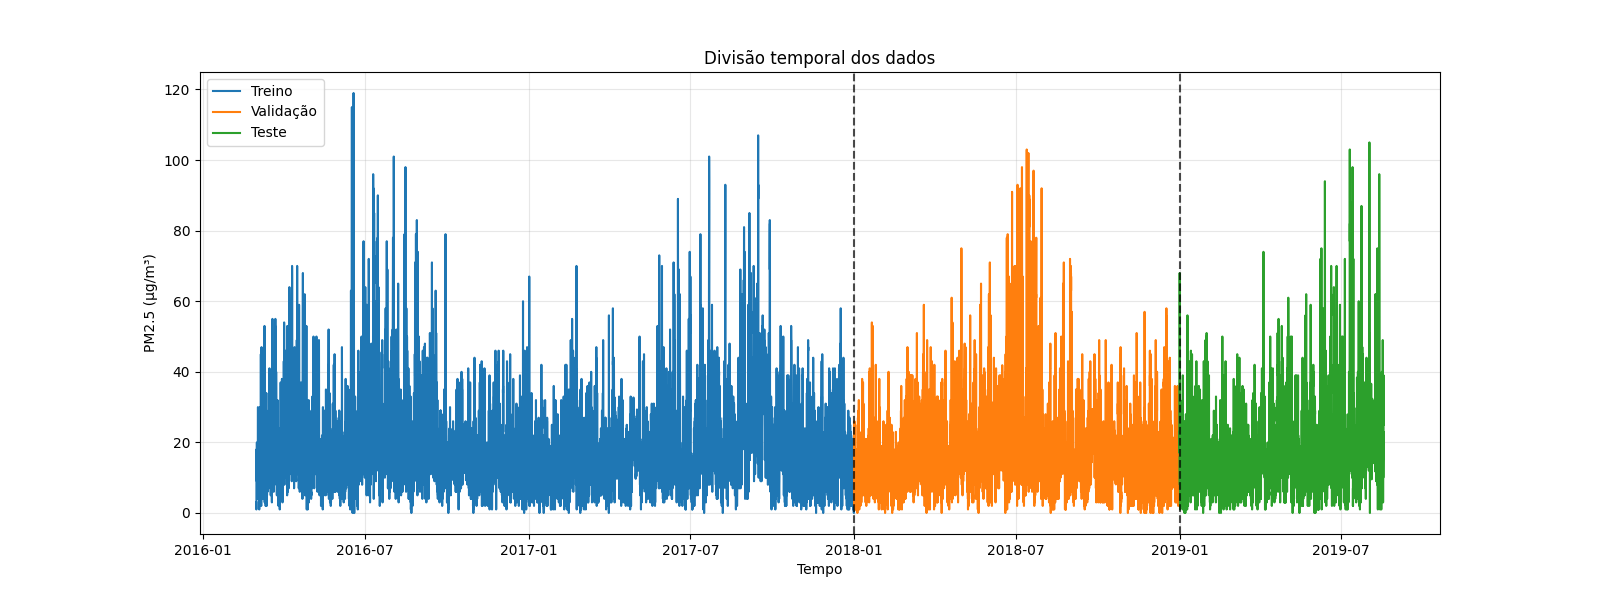

In [63]:
plt.figure(figsize=(16,6))

plt.plot(
    y_train,
    label="Treino",
    color="tab:blue"
)

plt.plot(
    y_val,
    label="Validação",
    color="tab:orange"
)

plt.plot(
    y_test,
    label="Teste",
    color="tab:green"
)

plt.axvline(
    y_val.index[0],
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.axvline(
    y_test.index[0],
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.title("Divisão temporal dos dados")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Tempo")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 6. Baseline simples

In [64]:
# Seasonal Naive (24h) - utilizado nas rodas simples do modelo (item 9.1)
# observado nas primeiras 24h do teste
y_true = y_val.iloc[:24]

# Baseline = ultimas 24h do treino
y_baseline = y_train.iloc[-24:].copy()

y_baseline.index = y_true.index

mae_baseline = mean_absolute_error(y_true, y_baseline)
rmse_baseline = root_mean_squared_error(y_true, y_baseline)
r2_baseline = r2_score(y_true, y_baseline)

print(f"Baseline 24h - MAE : {mae_baseline:.3f}")
print(f"Baseline 24h - RMSE: {rmse_baseline:.3f}")
print(f"Baseline 24h - R²  : {r2_baseline:.3f}")

Baseline 24h - MAE : 5.375
Baseline 24h - RMSE: 7.536
Baseline 24h - R²  : -0.304


### 7. Modelagem

**7.1 Modelo único para testes**

In [65]:
#Gridsearch do Gabriel indicou que o ótimo n_estimators=500, rodei com 1000 no modelo único para avaliar convergencia do learning_curve. Os outros parâmetros foram iguais ao melhor ajuste do Gabriel.
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=10,
    base_score=0.5,
    random_state=42,
    verbosity=0,
    tree_method="hist"
)

In [66]:
mask_train = X_train.notna().all(axis=1) & y_train.notna()
mask_val   = X_val.notna().all(axis=1)   & y_val.notna()

results = model.fit(
    X_train[mask_train], y_train[mask_train],
    eval_set=[
        (X_train[mask_train], y_train[mask_train]),
        (X_val[mask_val],     y_val[mask_val])
    ],
    verbose=False
)

In [67]:
#  Feature importance — diagnóstico do modelo

def plot_feature_importance(model, X_train, top_n=20):
    """
    Mostra quais features o modelo está usando de fato.
    """
    imp = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    imp.plot(kind="barh", ax=ax)
    ax.invert_yaxis()
    ax.set_title(f"Feature Importance — Top {top_n}")
    ax.set_xlabel("Importância")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return imp

In [68]:
def prever_24h(model, X_val, horizon=24):
    """
    Previsão das próximas 24h — usa features já calculadas.
    Equivalente ao get_forecast do SARIMAX.
    """
    X_future = X_val.iloc[:horizon]
    y_pred   = model.predict(X_future)

    return pd.Series(y_pred, index=X_future.index, name="forecast")

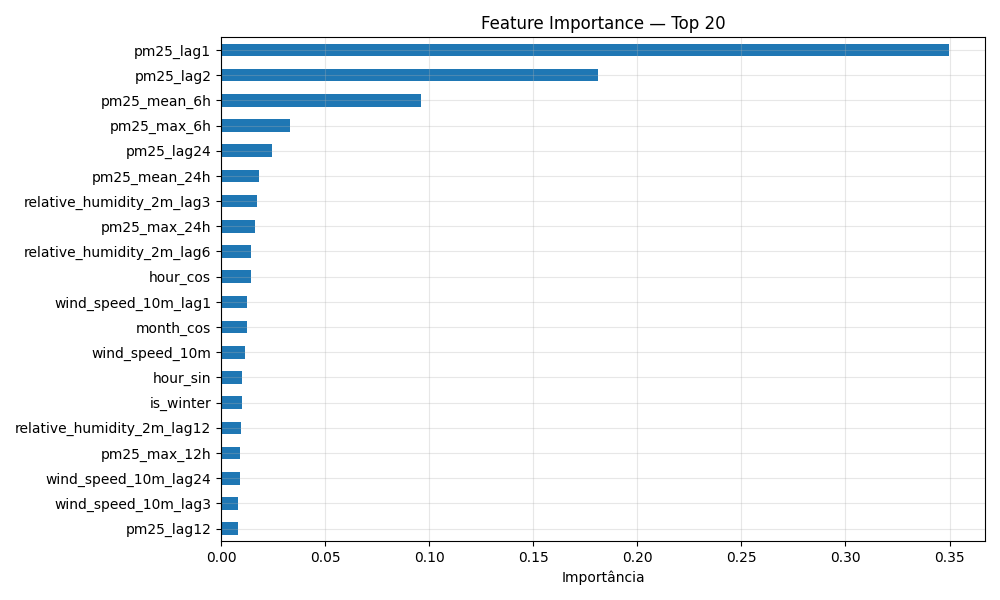

In [69]:
# feature importance
plot_feature_importance(results, X_train);


**SHAP — Interpretabilidade do XGBoost**

In [70]:
model_to_explain = model
explainer = shap.TreeExplainer(model_to_explain)


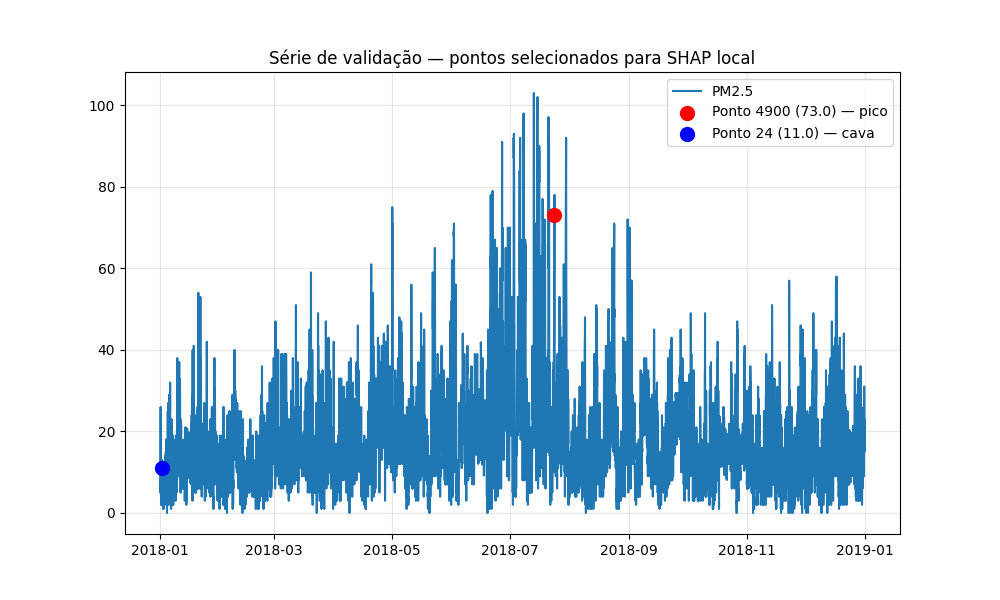

In [71]:
# SHAP Local — ponto específico (pico e cava)
plt.figure(figsize=(10, 6))
plt.plot(y_val, label="PM2.5")
plt.scatter(
    y_val.index[4900],
    y_val.iloc[4900],
    color="red", s=100, zorder=5,
    label=f"Ponto 4900 ({y_val.iloc[4900]:.1f}) — pico"
)
plt.scatter(
    y_val.index[24],
    y_val.iloc[24],
    color="blue", s=100, zorder=5,
    label=f"Ponto 24 ({y_val.iloc[24]:.1f}) — cava"
)
plt.legend()
plt.grid(alpha=0.3)
plt.title("Série de validação — pontos selecionados para SHAP local")
plt.show()


Previsão para o ponto 4900: 64.226 µg/m³
Valor de base:                           18.871
Soma dos SHAP values:                    45.355
Previsão do modelo:                      64.226


/tmp/ipykernel_5199/873717360.py:15: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


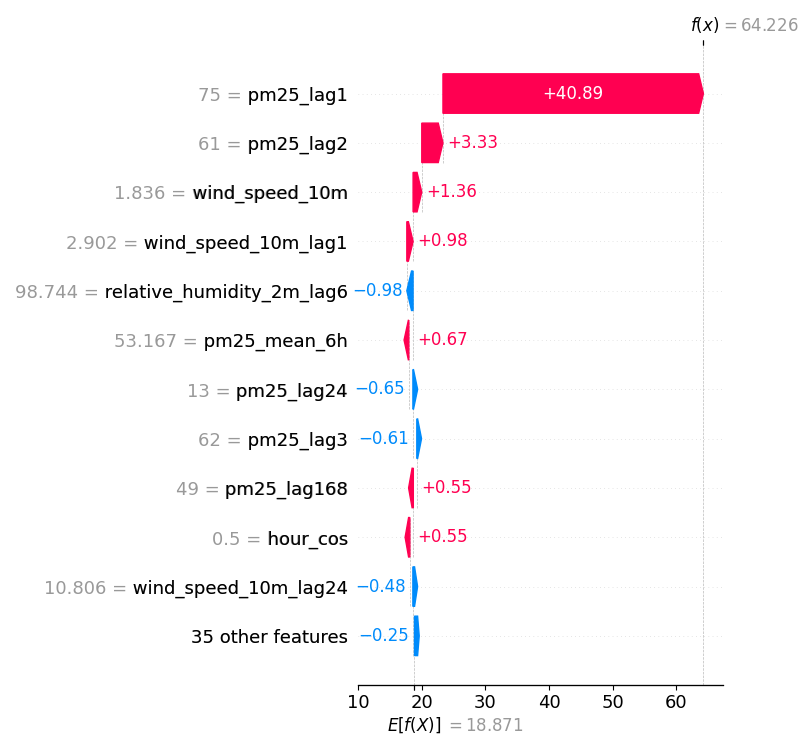

In [72]:
# --- SHAP local — pico (ponto 4900) ---
row_to_show    = 4900
feature_values = X_val.iloc[[row_to_show]]
prediction     = model_to_explain.predict(feature_values)

print(f"Previsão para o ponto {row_to_show}: {prediction[0]:.3f} µg/m³")

shap_vals_one = explainer.shap_values(feature_values)
shap_obj      = explainer(feature_values)

print(f"{'Valor de base:':<40}{explainer.expected_value:>7.3f}")
print(f"{'Soma dos SHAP values:':<40}{shap_vals_one[0].sum():>7.3f}")
print(f"{'Previsão do modelo:':<40}{prediction[0]:>7.3f}")

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_obj[0], max_display=12, show=False)
plt.tight_layout()
plt.show()


**Interpretação:**

  - Para o Pico vemos que a valor da MP2.5 no horário anterior é dominantes, isto é, se o valor está alto a tendência é permanecer. 
  - Vento tbm tem importância, vento fracos geram menor dispersão.

Previsão para o ponto 24: 10.882 µg/m³


Valor de base:                           18.871
Soma dos SHAP values:                    -7.989
Previsão do modelo:                      10.882


/tmp/ipykernel_5199/3793566910.py:15: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


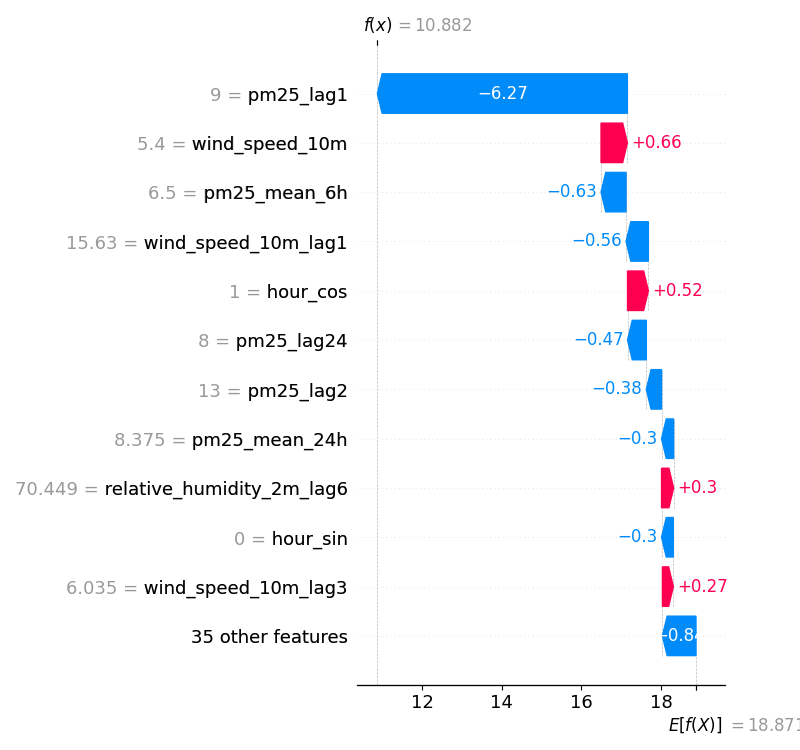

In [73]:
# --- SHAP local — cava (ponto 24) ---
row_to_show    = 24
feature_values = X_val.iloc[[row_to_show]]
prediction     = model_to_explain.predict(feature_values)

print(f"Previsão para o ponto {row_to_show}: {prediction[0]:.3f} µg/m³")

shap_vals_one = explainer.shap_values(feature_values)
shap_obj      = explainer(feature_values)

print(f"{'Valor de base:':<40}{explainer.expected_value:>7.3f}")
print(f"{'Soma dos SHAP values:':<40}{shap_vals_one[0].sum():>7.3f}")
print(f"{'Previsão do modelo:':<40}{prediction[0]:>7.3f}")

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_obj[0], max_display=12, show=False)
plt.tight_layout()
plt.show()

**Interpretação:**

   - Novamente o pm25_lag 1 dominante. Neste caso, se o valor está baixo puxa a previsão para baixo também. 
   - Vento também influenciando, mas no aumento dos valores. 

/tmp/ipykernel_5199/1533203436.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


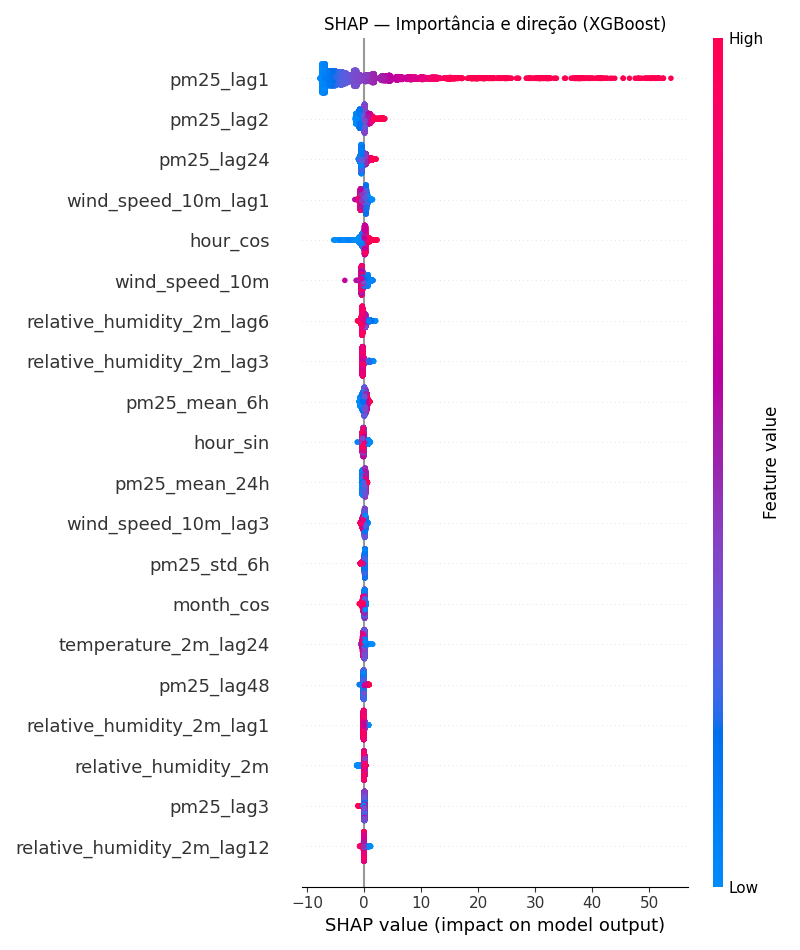

In [74]:
# SHAP Global
shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val, max_display=20, show=False)
plt.title("SHAP — Importância e direção (XGBoost)")
plt.tight_layout()
plt.show()

**Interpretação:**
  - pm25_lag1 — a minha feature mais importante. Indica que os valores de curto prazo dominam a previsão do modelo.
  - pm25_lag2 e pm25_lag24 — segunda e terceira mais importantes, com impacto muito menor. 
  - wind_speed_10m_lag1 e hour_cos — variáveis meteorológicas e temporais de maior impacto. Vento está associado a dispersão de poluentes e hour_cos a horários de maior pouluição (trânsito)

**Previsão inicial para as próximas 24h**

/tmp/ipykernel_5199/36895752.py:44: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(15, 6))


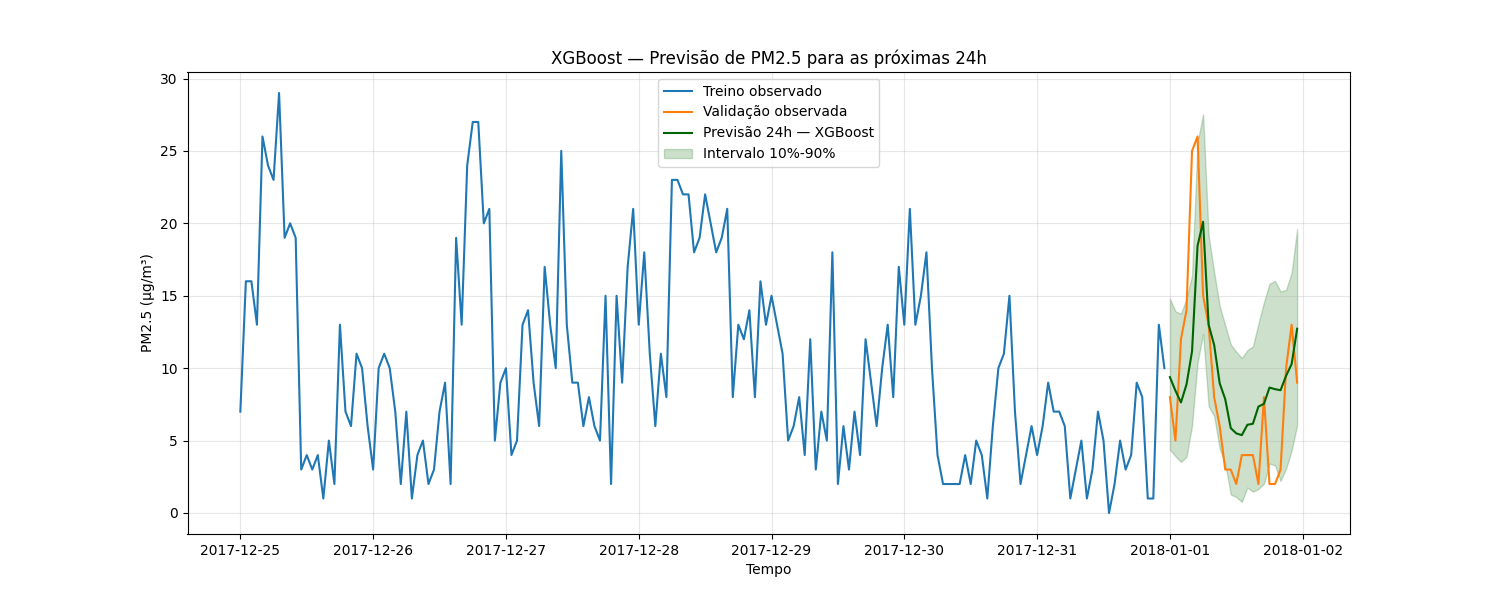

In [75]:
model_q10 = XGBRegressor(
    objective="reg:quantileerror",
    quantile_alpha=0.1,
    n_estimators=500,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=10,
    base_score=0.5,
    random_state=42,
    verbosity=0,
    tree_method="hist"
)

model_q90 = XGBRegressor(
    objective="reg:quantileerror",
    quantile_alpha=0.9,
    n_estimators=500,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=10,
    base_score=0.5,
    random_state=42,
    verbosity=0,
    tree_method="hist"
)

mask = X_train.notna().all(axis=1) & y_train.notna()
model_q10.fit(X_train[mask], y_train[mask])
model_q90.fit(X_train[mask], y_train[mask])

X_future  = X_val.iloc[:24]
pred_mean = pd.Series(model.predict(X_future),     index=X_future.index)
pred_low  = pd.Series(model_q10.predict(X_future), index=X_future.index)
pred_high = pd.Series(model_q90.predict(X_future), index=X_future.index)

plt.figure(figsize=(15, 6))

plt.plot(y_train.iloc[-24*7:], label="Treino observado")
plt.plot(y_val.iloc[:24],      label="Validação observada")
plt.plot(pred_mean, label="Previsão 24h — XGBoost", color="darkgreen")

plt.fill_between(
    pred_mean.index,
    pred_low,
    pred_high,
    alpha=0.2,
    color="darkgreen",
    label="Intervalo 10%-90%"
)

plt.title("XGBoost — Previsão de PM2.5 para as próximas 24h")
plt.xlabel("Tempo")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [76]:
error_mae = mean_absolute_error(
                y_true = y_val.iloc[:24],
                y_pred = pred_mean
            )
print(f"Test error (mae): {error_mae}")

Test error (mae): 3.9873724778493247


In [77]:
error_rmse = root_mean_squared_error(
    y_true=y_val.iloc[:24],
    y_pred=pred_mean
)

print(f"Test error (RMSE): {error_rmse:.3f}")

Test error (RMSE): 4.908


In [78]:
r2 = r2_score(
    y_true=y_val.iloc[:24],
    y_pred=pred_mean
)

print(f"R²: {r2:.4f}")

R²: 0.4470


**Learning Curve — XGBoost**

/tmp/ipykernel_5199/3414529353.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(14, 5))


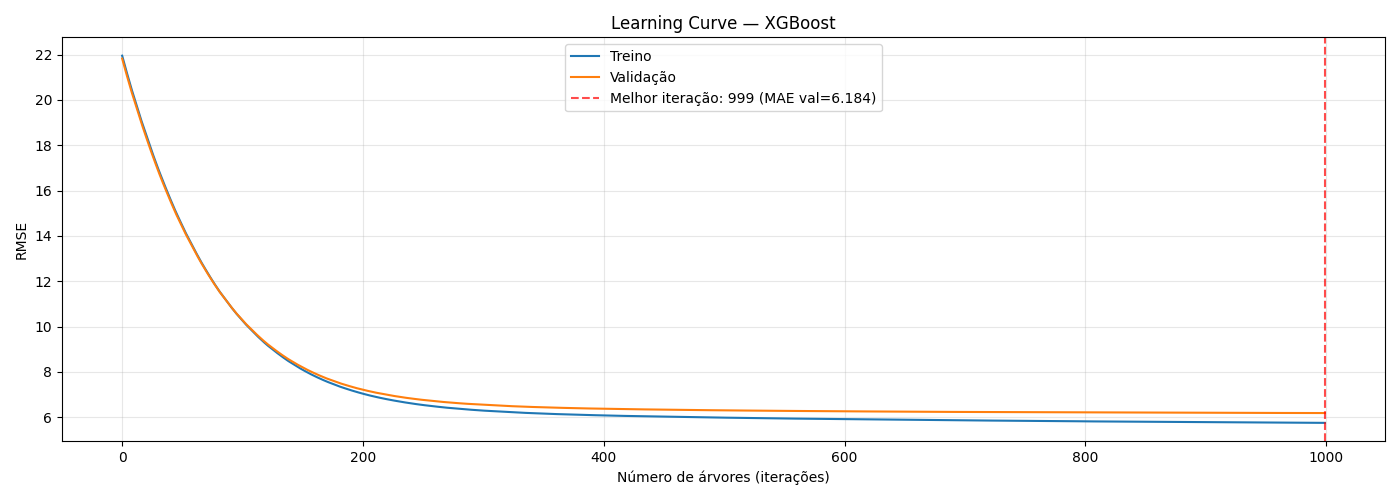

Melhor iteração : 999
RMSE treino      : 5.751
RMSE validação   : 6.184
Gap treino/val  : 0.433  (ideal próximo de 0)


In [79]:
mae_train = model.evals_result_["validation_0"]["rmse"]
mae_val   = model.evals_result_["validation_1"]["rmse"]


fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(mae_train, label="Treino",    color="tab:blue",   linewidth=1.5)
ax.plot(mae_val,   label="Validação", color="tab:orange", linewidth=1.5)


best_iter = np.argmin(mae_val)
ax.axvline(best_iter, color="red", linestyle="--", alpha=0.7,
           label=f"Melhor iteração: {best_iter} (MAE val={mae_val[best_iter]:.3f})")

ax.set_title("Learning Curve — XGBoost")
ax.set_xlabel("Número de árvores (iterações)")
ax.set_ylabel("RMSE")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Melhor iteração : {best_iter}")
print(f"RMSE treino      : {mae_train[best_iter]:.3f}")
print(f"RMSE validação   : {mae_val[best_iter]:.3f}")
print(f"Gap treino/val  : {mae_val[best_iter] - mae_train[best_iter]:.3f}  (ideal próximo de 0)")

No modelo único foi testado n_estimators=1000 para avaliar a convergência pela learning curve. A curva de validação estabiliza a partir de ~400 iterações, com ganho marginal até 999. 

O valor n_estimators=500 utilizado no walk-forward representa um compromisso entre desempenho e tempo de processamento, além disso, foi também o número obtido no GridSearch.

**7.2 Avaliação de todo o conjunto de validação** 

In [80]:
def walk_forward_xgboost(
    X_train, y_train,
    X_test,  y_test,
    horizon=24,
    step=24*7,
    start_inicial=0,
    output_file="walk_forward_xgboost.csv"
):
    """
    Walk-forward validation para XGBoost.
    Estrutura idêntica ao walk_forward_lgbm.
    """

    resultados = []

    X_total = pd.concat([X_train, X_test])
    y_total = pd.concat([y_train, y_test])

    n_test = len(y_test)

    for start in range(start_inicial, n_test - horizon + 1, step):

        print(f"Rodando previsão {start} até {start + horizon} de {n_test}...")

        X_train_i = X_total.iloc[:len(X_train) + start]
        y_train_i = y_total.iloc[:len(y_train) + start]

        X_true_i = X_test.iloc[start:start + horizon]
        y_true_i = y_test.iloc[start:start + horizon]

        # XGBoost não aceita NaN no y — remove ambos
        mask_train = X_train_i.notna().all(axis=1) & y_train_i.notna()

        X_fit = X_train_i[mask_train]
        y_fit = y_train_i[mask_train]

        model_i = XGBRegressor(
            n_estimators=500,
            learning_rate=0.01,
            max_depth=3,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=10,
            random_state=42,
            verbosity=0,
            tree_method="hist"
        )

        model_i.fit(X_fit, y_fit)

        y_pred_i = pd.Series(
            model_i.predict(X_true_i),
            index=y_true_i.index
        )

        y_baseline_i = y_total.iloc[
            len(y_train) + start - horizon : len(y_train) + start
        ].copy()
        y_baseline_i.index = y_true_i.index

        mask_eval = y_true_i.notna() & y_baseline_i.notna()

        if mask_eval.sum() == 0:
            continue

        mae  = mean_absolute_error(y_true_i[mask_eval], y_pred_i[mask_eval])
        rmse = np.sqrt(mean_squared_error(y_true_i[mask_eval], y_pred_i[mask_eval]))
        r2   = r2_score(y_true_i[mask_eval], y_pred_i[mask_eval]) \
               if mask_eval.sum() > 1 else np.nan

        mae_baseline  = mean_absolute_error(y_true_i[mask_eval], y_baseline_i[mask_eval])
        rmse_baseline = np.sqrt(mean_squared_error(y_true_i[mask_eval], y_baseline_i[mask_eval]))
        r2_baseline   = r2_score(y_true_i[mask_eval], y_baseline_i[mask_eval]) \
                        if mask_eval.sum() > 1 else np.nan

        melhora_mae  = 100 * (mae_baseline - mae)  / mae_baseline  if mae_baseline  != 0 else np.nan
        melhora_rmse = 100 * (rmse_baseline - rmse) / rmse_baseline if rmse_baseline != 0 else np.nan

        resultados.append({
            "start"           : start,
            "inicio_previsao" : y_true_i.index[0],
            "fim_previsao"    : y_true_i.index[-1],
            "mes"             : str(y_true_i.index[0].to_period("M")),
            "n_obs"           : mask_eval.sum(),

            "mae_xgboost"     : mae,
            "rmse_xgboost"    : rmse,
            "r2_xgboost"      : r2,

            "mae_baseline"    : mae_baseline,
            "rmse_baseline"   : rmse_baseline,
            "r2_baseline"     : r2_baseline,

            "melhora_mae_%"   : melhora_mae,
            "melhora_rmse_%"  : melhora_rmse
        })

        pd.DataFrame(resultados).to_csv(output_file, index=False)

    return pd.DataFrame(resultados)

In [81]:
df_walk_val = walk_forward_xgboost(
    X_train, y_train,
    X_val,   y_val,
    horizon=24,
    step=24*7,
    output_file="../results/walk_forward_xgboost_val.csv"
)

Rodando previsão 0 até 24 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 168 até 192 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 336 até 360 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 504 até 528 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 672 até 696 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 840 até 864 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1008 até 1032 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1176 até 1200 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1344 até 1368 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1512 até 1536 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1680 até 1704 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1848 até 1872 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2016 até 2040 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2184 até 2208 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2352 até 2376 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2520 até 2544 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2688 até 2712 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2856 até 2880 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3024 até 3048 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3192 até 3216 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3360 até 3384 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3528 até 3552 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3696 até 3720 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3864 até 3888 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4032 até 4056 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4200 até 4224 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4368 até 4392 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4536 até 4560 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4704 até 4728 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4872 até 4896 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5040 até 5064 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5208 até 5232 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5376 até 5400 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5544 até 5568 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5712 até 5736 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5880 até 5904 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 6048 até 6072 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 6216 até 6240 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 6384 até 6408 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 6552 até 6576 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 6720 até 6744 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 6888 até 6912 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 7056 até 7080 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 7224 até 7248 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 7392 até 7416 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 7560 até 7584 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 7728 até 7752 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 7896 até 7920 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 8064 até 8088 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 8232 até 8256 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 8400 até 8424 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 8568 até 8592 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 8736 até 8760 de 8760...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


In [82]:
df_walk_val[["mae_xgboost", "rmse_xgboost", "r2_xgboost",
         "mae_baseline", "melhora_mae_%"]].describe()

,mae_xgboost,rmse_xgboost,r2_xgboost,mae_baseline,melhora_mae_%
count,53.000000,53.000000,53.000000,53.000000,53.000000
mean,4.199588,5.349938,0.309445,8.109690,43.443168
std,1.471236,1.906174,0.299223,3.979373,17.585676
min,1.579142,2.124169,-0.328567,2.469284,1.442986
25%,3.251719,4.279698,0.095513,5.375000,30.205785
50%,4.082083,5.264061,0.320058,7.375000,45.505191
75%,4.979946,5.903768,0.511169,9.166667,56.683105
max,8.232471,11.578395,0.911640,23.541667,80.255944


**7.3 Comparando o desempenho na validação dos diferentes modelos**

In [83]:
#abrindo resultados do conjunto de validação (Melhor SARIMAX)
best_sarimax = pd.read_csv('../results/walk_forward_parcial_temp_umi_prec_wind_101_val.csv')
best_sarimax["inicio_previsao"] = pd.to_datetime(best_sarimax["inicio_previsao"])

In [84]:
#abrindo resultados do conjunto de validação (LightGBM/Dart)
dart = pd.read_csv('../results/walk_forward_lgbm_dart_val.csv')
dart["inicio_previsao"] = pd.to_datetime(dart["inicio_previsao"])
dart.head()

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2018-01-01 00:00:00+00:00,2018-01-01 23:00:00+00:00,2018-01,24,4.150131,5.093606,0.404494,5.375000,7.536025,-0.303527,22.788264,32.409911
1,168,2018-01-08 00:00:00+00:00,2018-01-08 23:00:00+00:00,2018-01,24,3.409447,4.175191,-0.083985,5.750000,7.088723,-2.124690,40.705269,41.100954
2,336,2018-01-15 00:00:00+00:00,2018-01-15 23:00:00+00:00,2018-01,24,1.987752,2.336716,-0.005073,5.686699,6.360743,-6.447345,65.045589,63.263470
3,504,2018-01-22 00:00:00+00:00,2018-01-22 23:00:00+00:00,2018-01,24,3.554726,4.640320,0.380327,8.666667,11.210114,-2.616488,58.983931,58.605952
4,672,2018-01-29 00:00:00+00:00,2018-01-29 23:00:00+00:00,2018-01,24,4.683204,5.970148,0.391572,13.916667,16.196707,-3.478084,66.348233,63.139745


In [85]:
dart[["mae_lgbm", "rmse_lgbm", "r2_lgbm",
         "mae_baseline", "melhora_mae_%"]].describe()

,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,melhora_mae_%
count,53.000000,53.000000,53.000000,53.000000,53.000000
mean,4.307223,5.550119,0.262758,8.109690,42.117169
std,1.516477,2.007453,0.320178,3.979373,16.115970
min,1.987752,2.336716,-0.475311,2.469284,6.859428
25%,3.263639,4.175191,0.065987,5.375000,30.850302
50%,4.102720,5.276333,0.357919,7.375000,41.579179
75%,4.981934,6.176807,0.482984,9.166667,53.745669
max,8.303178,10.590698,0.868236,23.541667,79.654210


In [86]:
#abrindo resultados do melhor ajuste para o LightGBM
lgbm = pd.read_csv('../results/walk_forward_lgbm_val.csv')
lgbm["inicio_previsao"] = pd.to_datetime(lgbm["inicio_previsao"])
lgbm.head()

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2018-01-01 00:00:00+00:00,2018-01-01 23:00:00+00:00,2018-01,24,4.266157,5.085158,0.406468,5.375000,7.536025,-0.303527,20.629640,32.522004
1,168,2018-01-08 00:00:00+00:00,2018-01-08 23:00:00+00:00,2018-01,24,3.494344,4.308546,-0.154336,5.750000,7.088723,-2.124690,39.228793,39.219720
2,336,2018-01-15 00:00:00+00:00,2018-01-15 23:00:00+00:00,2018-01,24,1.719282,2.039385,0.234431,5.686699,6.360743,-6.447345,69.766604,67.937945
3,504,2018-01-22 00:00:00+00:00,2018-01-22 23:00:00+00:00,2018-01,24,3.742925,4.585723,0.394823,8.666667,11.210114,-2.616488,56.812401,59.092987
4,672,2018-01-29 00:00:00+00:00,2018-01-29 23:00:00+00:00,2018-01,24,4.524866,5.689381,0.447454,13.916667,16.196707,-3.478084,67.485992,64.873227


In [87]:
lgbm[["mae_lgbm", "rmse_lgbm", "r2_lgbm",
         "mae_baseline", "melhora_mae_%"]].describe()

,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,melhora_mae_%
count,53.000000,53.000000,53.000000,53.000000,53.000000
mean,4.142572,5.276041,0.327092,8.109690,44.116241
std,1.413228,1.863307,0.299151,3.979373,17.163972
min,1.719282,2.039385,-0.332659,2.469284,5.365366
25%,3.249359,4.284883,0.126096,5.375000,31.749119
50%,4.025767,5.112583,0.394823,7.375000,46.631157
75%,4.869907,6.160081,0.542574,9.166667,58.178652
max,7.601361,10.907323,0.908974,23.541667,79.970929


In [88]:
#abrindo resultados do melhor ajuste para o XGboost
xgboost = pd.read_csv('../results/walk_forward_xgboost_val.csv')
xgboost["inicio_previsao"] = pd.to_datetime(xgboost["inicio_previsao"])
xgboost.head()

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_xgboost,rmse_xgboost,r2_xgboost,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2018-01-01 00:00:00+00:00,2018-01-01 23:00:00+00:00,2018-01,24,4.390907,5.129222,0.396137,5.375000,7.536025,-0.303527,18.308711,31.937293
1,168,2018-01-08 00:00:00+00:00,2018-01-08 23:00:00+00:00,2018-01,24,3.404898,4.224220,-0.109593,5.750000,7.088723,-2.124690,40.784389,40.409305
2,336,2018-01-15 00:00:00+00:00,2018-01-15 23:00:00+00:00,2018-01,24,1.768242,2.124169,0.169453,5.686699,6.360743,-6.447345,68.905655,66.605013
3,504,2018-01-22 00:00:00+00:00,2018-01-22 23:00:00+00:00,2018-01,24,4.082083,4.928407,0.300995,8.666667,11.210114,-2.616488,52.899043,56.036066
4,672,2018-01-29 00:00:00+00:00,2018-01-29 23:00:00+00:00,2018-01,24,4.224295,5.351311,0.511169,13.916667,16.196707,-3.478084,69.645787,66.960503


In [89]:
xgboost[["mae_xgboost", "rmse_xgboost", "r2_xgboost",
         "mae_baseline", "melhora_mae_%"]].describe()

,mae_xgboost,rmse_xgboost,r2_xgboost,mae_baseline,melhora_mae_%
count,53.000000,53.000000,53.000000,53.000000,53.000000
mean,4.199588,5.349938,0.309445,8.109690,43.443168
std,1.471236,1.906174,0.299223,3.979373,17.585676
min,1.579142,2.124169,-0.328567,2.469284,1.442986
25%,3.251719,4.279698,0.095513,5.375000,30.205785
50%,4.082083,5.264061,0.320058,7.375000,45.505191
75%,4.979946,5.903768,0.511169,9.166667,56.683105
max,8.232471,11.578395,0.911640,23.541667,80.255944


/tmp/ipykernel_5199/1687542810.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(14,5))


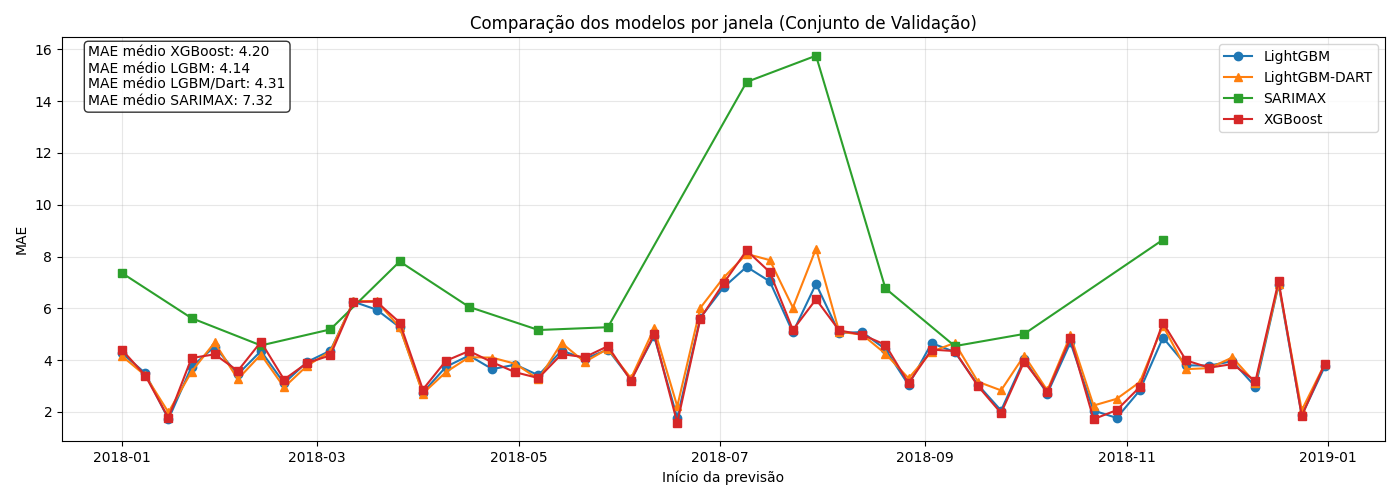

In [90]:
mae_lgbm = lgbm["mae_lgbm"].mean()
mae_dart = dart["mae_lgbm"].mean()
mae_sarimax = best_sarimax["mae_sarimax"].mean()
mae_xgboost = xgboost["mae_xgboost"].mean()

plt.figure(figsize=(14,5))

# LightGBM
plt.plot(
    lgbm["inicio_previsao"],
    lgbm["mae_lgbm"],
    marker="o",
    label="LightGBM"
)

# DART
plt.plot(
    dart["inicio_previsao"],
    dart["mae_lgbm"],
    marker="^",
    label="LightGBM-DART"
)

# SARIMAX
plt.plot(
    best_sarimax["inicio_previsao"],
    best_sarimax["mae_sarimax"],
    marker="s",
    label="SARIMAX"
)


# XGBoost
plt.plot(
    xgboost["inicio_previsao"],
    xgboost["mae_xgboost"],
    marker="s",
    label="XGBoost"
)

texto = (
    f"MAE médio XGBoost: {mae_xgboost:.2f}\n"
    f"MAE médio LGBM: {mae_lgbm:.2f}\n"
    f"MAE médio LGBM/Dart: {mae_dart:.2f}\n"
    f"MAE médio SARIMAX: {mae_sarimax:.2f}"
)

plt.text(
    0.02,
    0.98,
    texto,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8
    )
)

plt.title("Comparação dos modelos por janela (Conjunto de Validação)")
plt.xlabel("Início da previsão")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_5199/1206757681.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(14,5))


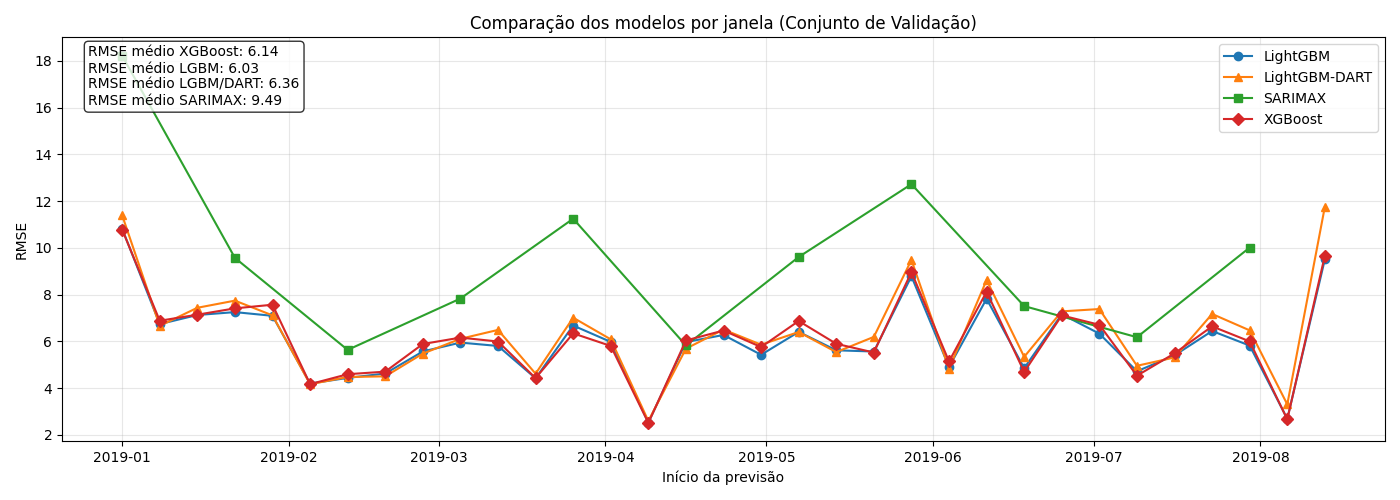

In [99]:
rmse_lgbm = lgbm["rmse_lgbm"].mean()
rmse_dart = dart["rmse_lgbm"].mean()
rmse_sarimax = best_sarimax["rmse_sarimax"].mean()
rmse_xgboost = xgboost["rmse_xgboost"].mean()

plt.figure(figsize=(14,5))

# LightGBM
plt.plot(
    lgbm["inicio_previsao"],
    lgbm["rmse_lgbm"],
    marker="o",
    label="LightGBM"
)

# DART
plt.plot(
    dart["inicio_previsao"],
    dart["rmse_lgbm"],
    marker="^",
    label="LightGBM-DART"
)

# SARIMAX
plt.plot(
    best_sarimax["inicio_previsao"],
    best_sarimax["rmse_sarimax"],
    marker="s",
    label="SARIMAX"
)

# XGBoost
plt.plot(
    xgboost["inicio_previsao"],
    xgboost["rmse_xgboost"],
    marker="D",
    label="XGBoost"
)

texto = (
    f"RMSE médio XGBoost: {rmse_xgboost:.2f}\n"
    f"RMSE médio LGBM: {rmse_lgbm:.2f}\n"
    f"RMSE médio LGBM/DART: {rmse_dart:.2f}\n"
    f"RMSE médio SARIMAX: {rmse_sarimax:.2f}"
)

plt.text(
    0.02,
    0.98,
    texto,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8
    )
)

plt.title("Comparação dos modelos por janela (Conjunto de Validação)")
plt.xlabel("Início da previsão")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_5199/65283030.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(14,5))


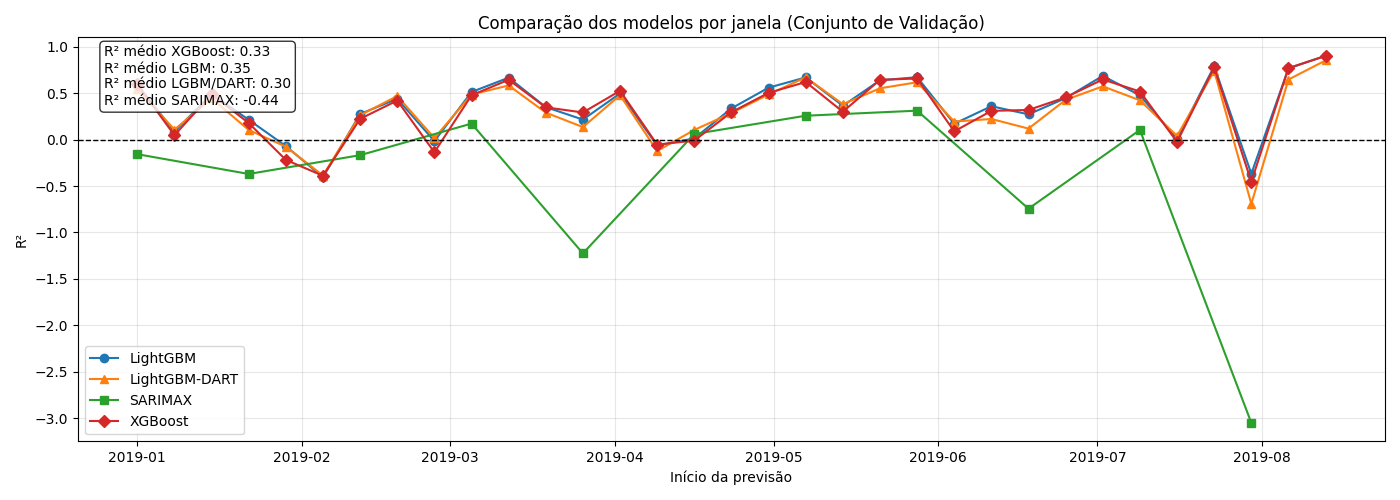

In [100]:
r2_lgbm = lgbm["r2_lgbm"].mean()
r2_dart = dart["r2_lgbm"].mean()
r2_sarimax = best_sarimax["r2_sarimax"].mean()
r2_xgboost = xgboost["r2_xgboost"].mean()

plt.figure(figsize=(14,5))

# LightGBM
plt.plot(
    lgbm["inicio_previsao"],
    lgbm["r2_lgbm"],
    marker="o",
    label="LightGBM"
)

# DART
plt.plot(
    dart["inicio_previsao"],
    dart["r2_lgbm"],
    marker="^",
    label="LightGBM-DART"
)

# SARIMAX
plt.plot(
    best_sarimax["inicio_previsao"],
    best_sarimax["r2_sarimax"],
    marker="s",
    label="SARIMAX"
)

# XGBoost
plt.plot(
    xgboost["inicio_previsao"],
    xgboost["r2_xgboost"],
    marker="D",
    label="XGBoost"
)

texto = (
    f"R² médio XGBoost: {r2_xgboost:.2f}\n"
    f"R² médio LGBM: {r2_lgbm:.2f}\n"
    f"R² médio LGBM/DART: {r2_dart:.2f}\n"
    f"R² médio SARIMAX: {r2_sarimax:.2f}"
)

plt.text(
    0.02,
    0.98,
    texto,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8
    )
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("Comparação dos modelos por janela (Conjunto de Validação)")
plt.xlabel("Início da previsão")
plt.ylabel("R²")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**SearchGRID**

Melhores parâmetros foram retirados do trabalho feito pelo Gabriel:

**Estratégia 3**

Melhores parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 10, 'subsample': 0.8}


**7.4 Avaliação de todo o conjunto de teste** 

In [91]:
df_walk_test = walk_forward_xgboost(
    X_train, y_train,
    X_test, y_test,
    horizon=24,
    step=24*7,
    output_file="../results/walk_forward_xgboost_test.csv"
)

Rodando previsão 0 até 24 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 168 até 192 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 336 até 360 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 504 até 528 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 672 até 696 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 840 até 864 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1008 até 1032 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1176 até 1200 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1344 até 1368 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1512 até 1536 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1680 até 1704 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1848 até 1872 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2016 até 2040 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2184 até 2208 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2352 até 2376 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2520 até 2544 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2688 até 2712 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2856 até 2880 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3024 até 3048 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3192 até 3216 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3360 até 3384 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3528 até 3552 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3696 até 3720 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3864 até 3888 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4032 até 4056 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4200 até 4224 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4368 até 4392 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4536 até 4560 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4704 até 4728 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4872 até 4896 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5040 até 5064 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5208 até 5232 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5376 até 5400 de 5499...


/tmp/ipykernel_5199/2896035994.py:85: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


In [92]:
df_walk_test[["mae_xgboost", "rmse_xgboost", "r2_xgboost",
         "mae_baseline", "melhora_mae_%"]].describe()

,mae_xgboost,rmse_xgboost,r2_xgboost,mae_baseline,melhora_mae_%
count,33.000000,33.000000,33.000000,33.000000,33.000000
mean,4.804406,6.141041,0.326114,9.282059,40.612648
std,1.334702,1.738414,0.338630,5.401545,18.259079
min,1.895621,2.514229,-0.453660,2.391270,-7.583758
25%,3.846820,5.139968,0.088936,6.125000,29.113756
50%,4.863149,5.997963,0.347686,7.541667,43.418692
75%,5.358201,6.881829,0.594829,11.708333,52.791488
max,8.576213,10.780247,0.900522,31.000000,76.137591


In [93]:
#abrindo teste do melhor SARIMAX
best_sarimax = pd.read_csv('../results/walk_forward_parcial_temp_umi_prec_wind_101_teste.csv')
best_sarimax["inicio_previsao"] = pd.to_datetime(best_sarimax["inicio_previsao"])

In [94]:
#abrindo resultados do conjunto de validação (LightGBM/Dart)
dart = pd.read_csv('../results/walk_forward_lgbm_dart_test.csv')
dart["inicio_previsao"] = pd.to_datetime(dart["inicio_previsao"])
dart.head()

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2019-01-01 00:00:00+00:00,2019-01-01 23:00:00+00:00,2019-01,24,8.597631,11.393137,0.547449,18.166667,24.262454,-1.052345,52.673591,53.042110
1,168,2019-01-08 00:00:00+00:00,2019-01-08 23:00:00+00:00,2019-01,24,4.933697,6.663466,0.107003,6.666667,8.341663,-0.399441,25.994538,20.118246
2,336,2019-01-15 00:00:00+00:00,2019-01-15 23:00:00+00:00,2019-01,24,5.489639,7.436280,0.444200,9.666667,11.765061,-0.391219,43.210628,36.793528
3,504,2019-01-22 00:00:00+00:00,2019-01-22 23:00:00+00:00,2019-01,24,6.476595,7.741749,0.103571,12.500000,14.753531,-2.255589,48.187241,47.526125
4,672,2019-01-29 00:00:00+00:00,2019-01-29 23:00:00+00:00,2019-01,24,5.422672,7.111371,-0.076031,10.791667,13.569267,-2.917698,49.751299,47.592073


In [95]:
#abrindo resultados do melhor ajuste para o LightGBM
lgbm = pd.read_csv('../results/walk_forward_lgbm_test.csv')
lgbm["inicio_previsao"] = pd.to_datetime(lgbm["inicio_previsao"])
lgbm.head()

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2019-01-01 00:00:00+00:00,2019-01-01 23:00:00+00:00,2019-01,24,8.558701,10.817917,0.591992,18.166667,24.262454,-1.052345,52.887882,55.412931
1,168,2019-01-08 00:00:00+00:00,2019-01-08 23:00:00+00:00,2019-01,24,5.192289,6.738938,0.086660,6.666667,8.341663,-0.399441,22.115667,19.213484
2,336,2019-01-15 00:00:00+00:00,2019-01-15 23:00:00+00:00,2019-01,24,5.689295,7.127129,0.489452,9.666667,11.765061,-0.391219,41.145221,39.421236
3,504,2019-01-22 00:00:00+00:00,2019-01-22 23:00:00+00:00,2019-01,24,5.859718,7.251251,0.213564,12.500000,14.753531,-2.255589,53.122256,50.850742
4,672,2019-01-29 00:00:00+00:00,2019-01-29 23:00:00+00:00,2019-01,24,5.749311,7.092264,-0.070257,10.791667,13.569267,-2.917698,46.724529,47.732887


In [96]:
#abrindo resultados do melhor ajuste para o XGboost
xgboost = pd.read_csv('../results/walk_forward_xgboost_test.csv')
xgboost["inicio_previsao"] = pd.to_datetime(xgboost["inicio_previsao"])
xgboost.head()

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_xgboost,rmse_xgboost,r2_xgboost,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2019-01-01 00:00:00+00:00,2019-01-01 23:00:00+00:00,2019-01,24,8.576213,10.780247,0.594829,18.166667,24.262454,-1.052345,52.791488,55.568191
1,168,2019-01-08 00:00:00+00:00,2019-01-08 23:00:00+00:00,2019-01,24,5.358290,6.881829,0.047517,6.666667,8.341663,-0.399441,19.625655,17.500506
2,336,2019-01-15 00:00:00+00:00,2019-01-15 23:00:00+00:00,2019-01,24,5.592222,7.140303,0.487563,9.666667,11.765061,-0.391219,42.149422,39.309258
3,504,2019-01-22 00:00:00+00:00,2019-01-22 23:00:00+00:00,2019-01,24,6.010634,7.411380,0.178446,12.500000,14.753531,-2.255589,51.914931,49.765380
4,672,2019-01-29 00:00:00+00:00,2019-01-29 23:00:00+00:00,2019-01,24,6.164061,7.566968,-0.218322,10.791667,13.569267,-2.917698,42.881289,44.234512


In [97]:
xgboost[["mae_xgboost", "rmse_xgboost", "r2_xgboost",
         "mae_baseline", "melhora_mae_%"]].describe()

,mae_xgboost,rmse_xgboost,r2_xgboost,mae_baseline,melhora_mae_%
count,33.000000,33.000000,33.000000,33.000000,33.000000
mean,4.804406,6.141041,0.326114,9.282059,40.612648
std,1.334702,1.738414,0.338630,5.401545,18.259079
min,1.895621,2.514229,-0.453660,2.391270,-7.583758
25%,3.846820,5.139968,0.088936,6.125000,29.113756
50%,4.863149,5.997963,0.347686,7.541667,43.418692
75%,5.358201,6.881829,0.594829,11.708333,52.791488
max,8.576213,10.780247,0.900522,31.000000,76.137591


/tmp/ipykernel_5199/3808464306.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(14,5))


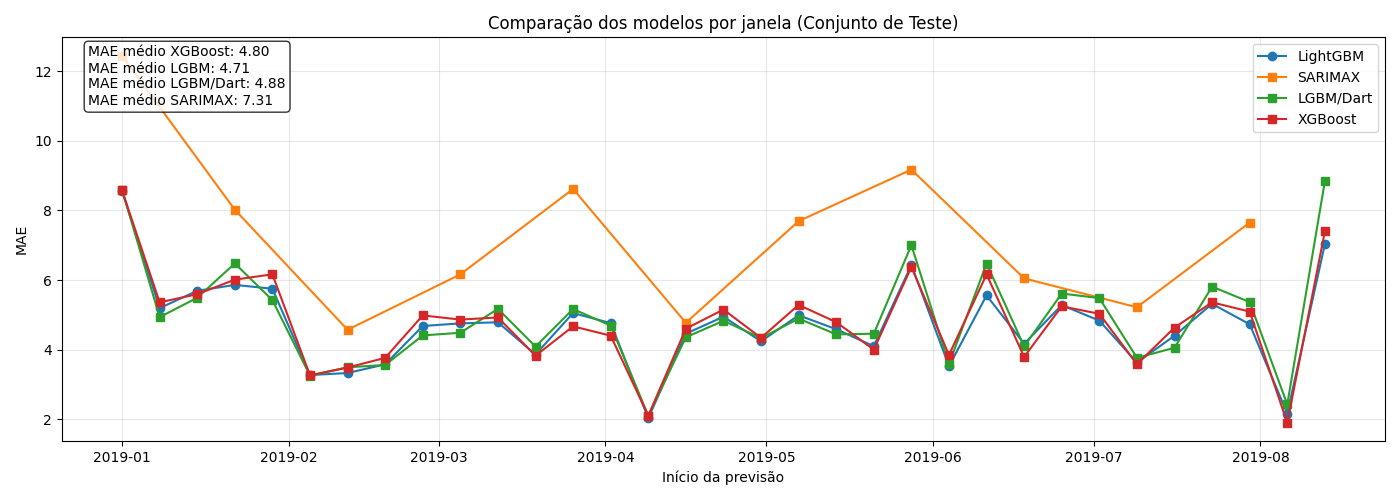

In [98]:
mae_lgbm = lgbm["mae_lgbm"].mean()
mae_dart = dart["mae_lgbm"].mean()
mae_sarimax = best_sarimax["mae_sarimax"].mean()
mae_xgboost = xgboost["mae_xgboost"].mean()

plt.figure(figsize=(14,5))

# LightGBM
plt.plot(
    lgbm["inicio_previsao"],
    lgbm["mae_lgbm"],
    marker="o",
    label="LightGBM"
)

# SARIMAX
plt.plot(
    best_sarimax["inicio_previsao"],
    best_sarimax["mae_sarimax"],
    marker="s",
    label="SARIMAX"
)

# DART
plt.plot(
    dart["inicio_previsao"],
    dart["mae_lgbm"],
    marker="s",
    label="LGBM/Dart"
)

# XGBoost
plt.plot(
    xgboost["inicio_previsao"],
    xgboost["mae_xgboost"],
    marker="s",
    label="XGBoost"
)

texto = (
    f"MAE médio XGBoost: {mae_xgboost:.2f}\n"
    f"MAE médio LGBM: {mae_lgbm:.2f}\n"
    f"MAE médio LGBM/Dart: {mae_dart:.2f}\n"
    f"MAE médio SARIMAX: {mae_sarimax:.2f}"
)

plt.text(
    0.02,
    0.98,
    texto,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8
    )
)

plt.title("Comparação dos modelos por janela (Conjunto de Teste)")
plt.xlabel("Início da previsão")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()